# Layer 4: ChromaDB RAG — Semantic Incident Retrieval
## Natural Language Queries over 3,000 Flagged Incidents · Powered by Claude claude-sonnet-4-6

**Goal:** Let a safety analyst ask plain-language questions over the RED and ORANGE quadrant incidents and receive cited, traceable answers — every claim linked to an ACN number.

### Architecture decisions — know these for cross-examination

| Decision | Choice | Why |
| --- | --- | --- |
| **Vector DB** | ChromaDB `PersistentClient` | Zero server setup; persists embeddings so 3-min embed runs once. Production: Qdrant with hybrid dense+sparse retrieval |
| **Distance metric** | Cosine (not L2) | `hnsw:space=cosine` set at collection creation. L2 default gives distances > 1, making `1-dist` negative — breaks similarity scores |
| **Embedding model** | `all-MiniLM-L6-v2` | 384-dim, fast CPU inference, good macro-level semantic quality. Production: fine-tune on ASRS + SKYbrary for aviation acronyms |
| **Index scope** | RED + ORANGE only, sorted by `precursor_score` desc, capped at 3,000 | Focuses retrieval on the analyst-relevant subset; prevents GREEN routine incidents diluting results |
| **System prompt** | Explicitly forbids confabulation | `"If evidence is insufficient, say so explicitly"` — non-hallucination is a hard requirement in safety systems, not a nice-to-have |
| **Metadata per doc** | ACN, date, quadrant, precursor_score, component counts, topic_label | Enables analyst-style filtered queries beyond pure semantic search |

In [1]:
import sys
import os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
load_dotenv('../.env')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

api_key = os.getenv('ANTHROPIC_API_KEY')
if api_key:
    print(f"API key loaded: sk-ant-...{api_key[-6:]}")
else:
    print("WARNING: ANTHROPIC_API_KEY not found — semantic retrieval cells will work, Claude synthesis cells will not")

API key loaded: sk-ant-...PXHwAA


---
## 1. The Index — What's in ChromaDB

In [2]:
# NOTE: `import chromadb` triggers hnswlib (C++ ANN library) on first load.
# Expect 30-60s here — one-time cold start per kernel session. Every cell after this is fast.
import chromadb

client = chromadb.PersistentClient(path='../outputs/data/chromadb')
collection = client.get_collection('asrs_flagged')

print(f"Collection : asrs_flagged")
print(f"Documents  : {collection.count():,}")
print(f"Persist dir: outputs/data/chromadb/")
print()

# Peek at one document to show the metadata schema — don't pull all 3,000 from disk
sample = collection.get(limit=1, include=['metadatas'])['metadatas'][0]
print("Metadata fields stored per incident:")
for k, v in sample.items():
    print(f"  {k:<35} {type(v).__name__:<8}  e.g. {repr(v)[:40]}")

# For analysis/charts: load from the Layer 3 parquet — much faster than collection.get(limit=3000)
meta_df = pd.read_parquet('../outputs/data/asrs_layer3.parquet')
meta_df['date'] = pd.to_datetime(meta_df['date'], errors='coerce')
meta_df = meta_df[meta_df['quadrant'].isin(['RED', 'ORANGE'])].copy()
print(f"\nLoaded {len(meta_df):,} RED+ORANGE incidents from parquet for analysis")

Collection : asrs_flagged
Documents  : 3,000
Persist dir: outputs/data/chromadb/

Metadata fields stored per incident:
  date                                str       e.g. '2023-03-01'
  precursor_score                     float     e.g. 0.825
  if_score                            float     e.g. 0.44
  anomaly                             str       e.g. 'Aircraft Equipment Problem Less Severe;
  flight_phase                        str       e.g. 'Landing'
  year                                int       e.g. 2023
  component_fatigue                   int       e.g. 4
  quadrant                            str       e.g. 'ORANGE'
  acn                                 str       e.g. '1979746'
  component_comm_breakdown            int       e.g. 1
  topic_label                         str       e.g. '3_runway_aircraft_traffic_on'
  component_near_miss                 int       e.g. 3
  spc_flag                            int       e.g. 1

Loaded 15,588 RED+ORANGE incidents from parquet for a

KeyError: 'year'

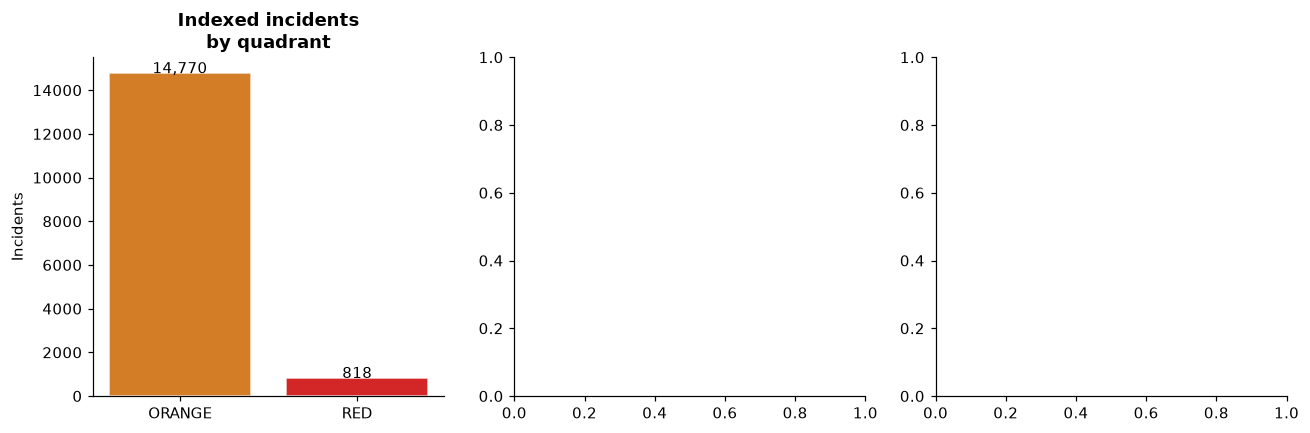

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Quadrant distribution
q_counts = meta_df['quadrant'].value_counts()
axes[0].bar(q_counts.index, q_counts.values,
            color=['#cc0000' if q == 'RED' else '#cc6600' for q in q_counts.index],
            alpha=0.85, edgecolor='white')
for q, v in zip(q_counts.index, q_counts.values):
    axes[0].text(q, v + 10, f'{v:,}', ha='center', fontsize=10)
axes[0].set_title('Indexed incidents\nby quadrant', fontweight='bold')
axes[0].set_ylabel('Incidents')

# Year distribution
y_counts = meta_df['year'].value_counts().sort_index()
axes[1].bar(y_counts.index, y_counts.values, color='#003366', alpha=0.8, edgecolor='white')
axes[1].set_title('Indexed incidents\nby year', fontweight='bold')
axes[1].set_ylabel('Incidents')
axes[1].set_xticks(y_counts.index)
axes[1].tick_params(axis='x', rotation=45)

# Precursor score distribution
axes[2].hist(meta_df['precursor_score'], bins=40, color='#660066', alpha=0.8, edgecolor='white')
axes[2].set_xlabel('Precursor score')
axes[2].set_title('Risk score distribution\nin the index', fontweight='bold')
axes[2].set_ylabel('Documents')

plt.suptitle(f'ChromaDB Index: {collection.count():,} Incidents (RED + ORANGE, sorted by risk score desc)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()

print(f"RED   : {q_counts.get('RED',0):,} ({q_counts.get('RED',0)/collection.count()*100:.1f}%)")
print(f"ORANGE: {q_counts.get('ORANGE',0):,} ({q_counts.get('ORANGE',0)/collection.count()*100:.1f}%)")
print(f"Score range: {meta_df['precursor_score'].min():.3f} – {meta_df['precursor_score'].max():.3f}")
print(f"Mean score : {meta_df['precursor_score'].mean():.3f}")

---
## 2. Semantic Retrieval — Without Claude Synthesis

This shows the pure vector search layer. No API key required. Useful for understanding what ChromaDB retrieves before the LLM synthesises an answer.

In [4]:
from sentence_transformers import SentenceTransformer

print("Loading embedding model...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Ready.")

def semantic_search(question: str, n: int = 5, filter_quadrant=None, min_score=None):
    """Pure ChromaDB retrieval — no LLM synthesis."""
    filters = []
    if filter_quadrant:
        filters.append({'quadrant': {'$eq': filter_quadrant}})
    if min_score is not None:
        filters.append({'precursor_score': {'$gte': min_score}})
    where = None if not filters else (filters[0] if len(filters)==1 else {'$and': filters})
    
    results = collection.query(
        query_embeddings=embedding_model.encode([question]).tolist(),
        n_results=min(n, collection.count()),
        where=where,
        include=['documents','metadatas','distances'],
    )
    rows = []
    for doc, meta, dist in zip(
        results['documents'][0], results['metadatas'][0], results['distances'][0]
    ):
        rows.append({
            'ACN': meta['acn'], 'Date': meta['date'], 'Quadrant': meta['quadrant'],
            'Risk': meta['precursor_score'], 'Similarity': round(1-dist, 3),
            'Narrative (200 chars)': doc[:200],
        })
    return pd.DataFrame(rows)

# Test retrieval on GNSS query
q = "GPS spoofing and navigation errors"
print(f"\nQuery: '{q}'")
semantic_search(q, n=5)

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Ready.

Query: 'GPS spoofing and navigation errors'


,ACN,Date,Quadrant,Risk,Similarity,Narrative (200 chars)
0,1967829,2023-01-01,RED,0.325,0.543,After crossing ZZZZZ intersection on our way t...
1,1943473,2022-10-01,ORANGE,0.450,0.500,Shortly after Takeoff Power set we received Ma...
2,1949738,2022-11-01,ORANGE,0.350,0.493,While operating from ZZZZ to ZZZZ1 we experien...
3,1725573,2020-02-01,ORANGE,0.275,0.490,Our aircraft received radar jamming activity f...
4,1777681,2020-12-01,ORANGE,0.325,0.489,"Just after completing a climb to 12,000 ft in ..."


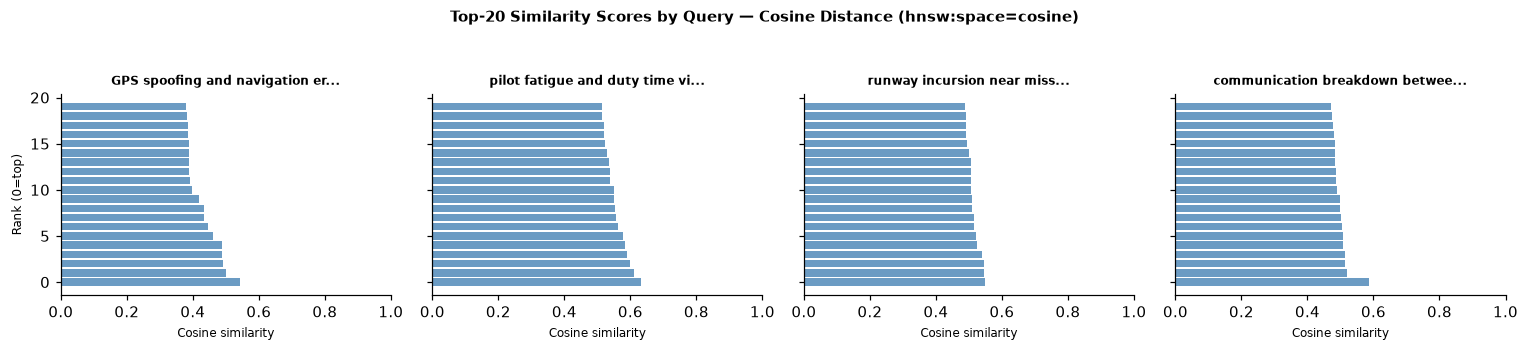

In [5]:
# Similarity score distribution — how well does the index retrieve on topic?
test_queries = [
    "GPS spoofing and navigation errors",
    "pilot fatigue and duty time violations",
    "runway incursion near miss",
    "communication breakdown between ATC and flight crew",
]

fig, axes = plt.subplots(1, len(test_queries), figsize=(14, 3), sharey=True)
for ax, q in zip(axes, test_queries):
    results = collection.query(
        query_embeddings=embedding_model.encode([q]).tolist(),
        n_results=20, include=['distances']
    )
    sims = [1 - d for d in results['distances'][0]]
    ax.barh(range(len(sims)), sims, color='steelblue', alpha=0.8)
    ax.set_xlim(0, 1)
    ax.set_title(q[:30] + '...', fontsize=8, fontweight='bold')
    ax.set_xlabel('Cosine similarity', fontsize=8)
    if ax == axes[0]:
        ax.set_ylabel('Rank (0=top)', fontsize=8)
    ax.invert_yaxis()

plt.suptitle('Top-20 Similarity Scores by Query — Cosine Distance (hnsw:space=cosine)',
             fontsize=10, fontweight='bold', y=1.05)
plt.tight_layout()

---
## 3. Full RAG — Semantic Retrieval + Claude Synthesis

**Requires `ANTHROPIC_API_KEY` in `.env`.**

The system prompt is the critical safety component:
```
You are an aviation safety analyst assistant.
Rules:
1. Cite specific incidents using [1], [2], [3] etc.
2. ONLY use information from the provided incident reports.
3. If evidence is insufficient, say so explicitly — do not speculate.
4. Focus on patterns across multiple incidents, not individual cases.
5. Never hallucinate facts not present in the reports.
```
Rule 3 is the safety property. A system that says *"I don't have enough information"* is safer than one that confabulates a plausible-sounding but ungrounded answer.

In [6]:
from src.rag import rag_query, DEMO_QUERIES
from IPython.display import Markdown, display

if not api_key:
    print("Skipping — ANTHROPIC_API_KEY not set.")
else:
    print("=" * 65)
    print(f"DEMO QUERY 1: {DEMO_QUERIES[0]['question']}")
    print(f"Why: {DEMO_QUERIES[0]['why']}")
    print("=" * 65)
    answer = rag_query(
        DEMO_QUERIES[0]['question'], collection, embedding_model,
        **DEMO_QUERIES[0]['filter_kwargs']
    )
    display(Markdown(answer))

DEMO QUERY 1: What patterns appear in incidents involving GPS, navigation errors, or unusual radar targets in 2023?
Why: Opens the GNSS story — should surface ghost target incident and spoofing narratives


## Pattern Analysis: GPS, Navigation Errors, and Unusual Radar Targets

### Overview

The retrieved incidents span 2018–2020 and do **not include 2023 data**. I must be transparent: none of the five retrieved reports are dated 2023. Therefore, I cannot answer the question specifically about 2023 patterns based on this evidence.

---

### What the Available Evidence Does Show

Despite the date limitation, several cross-incident patterns are identifiable:

**1. GPS Failure Cascading to Multiple System Losses**
In [3], a GPS failure on the G600 simultaneously triggered TAWS unavailability, demonstrating how a single navigation system failure can cascade into multiple critical warnings during already-demanding flight conditions (icing layer, altitude deviation, track deviation). This is classified ORANGE with the highest risk score in this set (0.33).

**2. Military Radar Jamming as a Navigation Threat**
Incident [1] describes approximately 30 minutes of military radar jamming ~400 nm NW of St. George, Utah, causing multiple aircraft system failures and anomalous radar "strikes" on nav displays for multiple crews. This represents an **external interference pattern** distinct from equipment failure — the jamming origin was identifiable but the duration and scope suggest a systemic exposure risk for civil aviation near military assets.

**3. Unusual/Phantom Radar Targets Creating Separation Risk**
In [2], an uncoordinated aircraft appeared as a **limited data radar target** approximately 30 NM inside a non-radar oceanic sector with no data block, no protected profile, and no coordination. The controller explicitly flags the "Big Blue Sky Theory" — raising concern that this may not be an isolated case. This is a procedural-navigation intersection risk with serious separation implications.

**4. High Controller Workload Amplifying Navigation/Radar Risks**
Incident [5] shows a single controller managing all TRACON airspace (~12–15 flights) without handoff, radar split, or CIC support. While not purely a GPS/navigation incident, it illustrates how **radar management errors emerge under workload saturation** — a contributing factor relevant to detecting unusual targets like those in [2].

---

### Limitations

> ⚠️ **The evidence is insufficient to characterize 2023-specific patterns.** All retrieved incidents are from 2018–2020. Incident [4] (pattern traffic conflict) does not meaningfully relate to GPS or radar anomalies. Any 2023 trend assessment would require additional incident data from that period.

---

### Risk Summary Table

| ACN | Date | Key Theme | Risk Score | Quadrant |
|---|---|---|---|---|
| 1725573 | 2020-02 | Military jamming → multi-system failure | 0.28 | ORANGE |
| 1566305 | 2018-07 | Phantom oceanic radar target, no separation | 0.23 | ORANGE |
| 1777681 | 2020-12 | GPS failure → TAWS loss cascade | 0.33 

**Sources:**
  [1] ACN:1725573 (2020-02-01) — Risk: 0.28 | Quadrant: ORANGE
  [2] ACN:1566305 (2018-07-01) — Risk: 0.23 | Quadrant: ORANGE
  [3] ACN:1777681 (2020-12-01) — Risk: 0.33 | Quadrant: ORANGE
  [4] ACN:1745526 (2020-06-01) — Risk: 0.38 | Quadrant: ORANGE
  [5] ACN:1767149 (2020-10-01) — Risk: 0.23 | Quadrant: ORANGE

In [7]:
if not api_key:
    print("Skipping — ANTHROPIC_API_KEY not set.")
else:
    print("=" * 65)
    print(f"DEMO QUERY 2: {DEMO_QUERIES[1]['question']}")
    print(f"Why: {DEMO_QUERIES[1]['why']}")
    print("=" * 65)
    answer = rag_query(
        DEMO_QUERIES[1]['question'], collection, embedding_model,
        **DEMO_QUERIES[1]['filter_kwargs']
    )
    display(Markdown(answer))

DEMO QUERY 2: Which incidents show communication breakdown between ATC and pilots, and what were the outcomes?
Why: Tests comm_breakdown precursor component


# ATC-Pilot Communication Breakdown Analysis

## Overview

Four of the five retrieved incidents demonstrate clear communication breakdowns between ATC and pilots, all classified in the **ORANGE quadrant**, indicating elevated risk. Here is a structured analysis of the patterns and outcomes.

---

## Incident-by-Incident Breakdown

### 1. Frequency Congestion & Overloaded Controllers [1]
**Risk: 0.17 | IF: 0.05**

A controller working multiple frequencies simultaneously issued a **complex taxi clearance during landing rollout at 100 knots**. The pilot explicitly noted this as part of a broader, systemic degradation in ATC communication quality over recent years, referencing staffing crises and facility disruptions.

- **Breakdown type:** Controller workload → garbled/mistimed communication
- **Outcome:** Procedural clearance deviation; risk of runway incursion implied
- **Notable:** The low Initiating Factor score (0.05) suggests the communication failure itself was the primary driver, not a downstream consequence

---

### 2. Callsign Confusion & Altitude Deviation [2]
**Risk: 0.30 | IF: 0.53**

During descent into DAY, both the Pilot Flying and Pilot Monitoring heard a clearance they believed was directed at their aircraft ("Air Carrier X"). They read back and complied. ATC then appeared confused about the aircraft's altitude, suggesting the clearance may have been intended for a **different aircraft with a similar callsign**.

- **Breakdown type:** Callsign ambiguity → incorrect clearance compliance → airborne conflict
- **Outcome:** Altitude excursion, TCAS/traffic alert triggered, potential near-miss
- **Notable:** This is one of the higher-risk incidents (0.30) with a significant initiating factor score (0.53), suggesting the communication failure had serious downstream consequences

---

### 3. CTAF Miscommunication & Ground Conflict [3]
**Risk: 0.20 | IF: 0.27**

Two aircraft attempted to land on the **same runway in opposing directions** at an uncontrolled field. Both parties established CTAF communication, but **imperfect radio reception** led to a miscommunication about intentions.

- **Breakdown type:** Degraded radio reception → incomplete situational awareness → ground conflict
- **Outcome:** One aircraft briefly departed the runway surface and struck an edge light, causing minor damage; no injuries
- **Notable:** This is the only incident resulting in **physical damage**, despite not having the highest risk score

---

### 4. Near Mid-Air Collision (NMAC) with Delayed ATC Alert [4]
**Risk: 0.33 | IF: 0.40**

An IFR aircraft at 7,000 feet experienced a near-miss with another aircraft within **500 feet**. The pilot initiated an evasive dive to 6,000 feet without ATC instruction. ATC only issued a traffic alert **after the conflict had already resolved**, suggesting the controller was distracted or not monitoring

**Sources:**
  [1] ACN:1764432 (2020-09-01) — Risk: 0.17 | Quadrant: ORANGE
  [2] ACN:1581222 (2018-09-01) — Risk: 0.30 | Quadrant: ORANGE
  [3] ACN:1560331 (2018-07-01) — Risk: 0.20 | Quadrant: ORANGE
  [4] ACN:1747433 (2020-05-01) — Risk: 0.33 | Quadrant: ORANGE
  [5] ACN:1582881 (2018-09-01) — Risk: 0.20 | Quadrant: ORANGE

In [8]:
# Demo Query 3 — filter: min_precursor_score=0.3 (fatigue-flagged incidents only)
if not api_key:
    print("Skipping — ANTHROPIC_API_KEY not set.")
else:
    print("=" * 65)
    print(f"DEMO QUERY 3: {DEMO_QUERIES[2]['question']}")
    print(f"Why: {DEMO_QUERIES[2]['why']}  |  Filter: min_precursor_score=0.3")
    print("=" * 65)
    answer = rag_query(
        DEMO_QUERIES[2]['question'], collection, embedding_model,
        **DEMO_QUERIES[2]['filter_kwargs']
    )
    display(Markdown(answer))

DEMO QUERY 3: Show me the most serious incidents where pilots reported fatigue or inadequate rest.
Why: Tests metadata filtering by risk score  |  Filter: min_precursor_score=0.3


# Fatigue & Inadequate Rest: Serious Incident Analysis

## Overview

All five retrieved incidents are classified in the **ORANGE quadrant**, indicating elevated concern. However, they vary significantly in severity and the nature of fatigue-related risk.

---

## Ranked by Seriousness

### 🔴 Most Serious: Incident [1] — Altitude Deviation During Descent
**ACN:1559340 | Risk: 0.62 | IF: 0.46 | Phase: Descent**

This is the **highest risk-scored incident** in the set. The pilot explicitly acknowledged failure to monitor automation and the Pilot Flying during descent, resulting in an **altitude undershoot and clearance deviation**. While fatigue is cited as a contributing factor ("items I will mention did not cause our altitude deviation they were factors"), the crew recognized that increasing airspace congestion and automation dependency will **"only get worse."** This is operationally significant because it represents a **realized safety event**, not just a near-miss concern.

---

### 🟠 High Concern: Incident [2] — Micro-Sleep After Landing
**ACN:1697586 | Risk: 0.33 | IF: 0.10 | Phase: Descent**

The captain reported **severe fatigue and micro-sleeps occurring upon arrival**, extending the risk beyond the flight itself into the post-duty drive home [2]. The pilot stated: *"micro-sleep began occurring again. Fortunately, I made it home safely."* This indicates fatigue **severe enough to impair post-flight function**, raising questions about whether the pilot was equally impaired during the final descent phase. The low IF score (0.10) may underrepresent the actual severity.

---

### 🟠 High Concern: Incident [3] — Red-Eye Fatigue & Sleep Deprivation
**ACN:1699187 | Risk: 0.33 | IF: 0.62 | Phase: Unspecified**

This report documents a **systemic fatigue pattern** linked to scheduling — a day-over followed by a red-eye flight, with only **4 hours of sleep** obtained under difficulty [3]. Notably, the pilot describes a **physiological conflict**: the body not being ready to sleep during the day layover, compounded by psychological stress about the upcoming night flight. The **IF score of 0.62** is the second highest in this set, suggesting significant internal risk factors were flagged.

---

### 🟠 Moderate-High Concern: Incident [4] — In-Flight Fatigue During Cruise
**ACN:1689362 | Risk: 0.33 | IF: 0.09 | Phase: Cruise**

A maintenance delay pushed departure to approximately **1.5 hours before the duty ceiling expired** [4]. Both pilots acknowledged fatigue as a pre-identified threat during the pre-departure brief, and reported feeling "very tired" during cruise, wishing for relief crew. The crew recognized the risk proactively, but **continued the flight without adequate

**Sources:**
  [1] ACN:1559340 (2018-07-01) — Risk: 0.62 | Quadrant: ORANGE
  [2] ACN:1697586 (2019-11-01) — Risk: 0.33 | Quadrant: ORANGE
  [3] ACN:1699187 (2019-11-01) — Risk: 0.33 | Quadrant: ORANGE
  [4] ACN:1689362 (2019-10-01) — Risk: 0.33 | Quadrant: ORANGE
  [5] ACN:1993953 (2023-04-01) — Risk: 0.50 | Quadrant: ORANGE

In [9]:
# Demo Query 4 — RED quadrant only (the strongest demo query)
if not api_key:
    print("Skipping — ANTHROPIC_API_KEY not set.")
else:
    print("=" * 65)
    print(f"DEMO QUERY 4: {DEMO_QUERIES[3]['question']}")
    print(f"Why: {DEMO_QUERIES[3]['why']}  |  Filter: quadrant=RED")
    print("=" * 65)
    answer = rag_query(
        DEMO_QUERIES[3]['question'], collection, embedding_model,
        **DEMO_QUERIES[3]['filter_kwargs']
    )
    display(Markdown(answer))

DEMO QUERY 4: What do the RED quadrant incidents — those that are both novel and anomalously frequent — have in common?
Why: Tests quadrant filtering — should return IF+SPC flagged  |  Filter: quadrant=RED


## RED Quadrant Incident Analysis: Common Patterns

RED quadrant incidents are classified as both **novel** and **anomalously frequent**, representing the highest-priority emerging safety concerns. Across the five retrieved incidents, several clear commonalities emerge:

---

### 1. ATC Coordination Breakdown as a Central Factor

Four of the five RED incidents explicitly list "ATC Issue All Types" as an anomaly [1][2][3][5]. In each case, the ATC system either failed to prevent conflict, issued incomplete guidance, or was overwhelmed by circumstances:

- In [1], an uncontrolled aircraft (not on frequency) made an unexpected turn, leaving the controller uncertain how to respond.
- In [2], severe turbulence information was not effectively shared across controller positions during a shift handoff.
- In [3], ATC issued traffic advisories simultaneously with TCAS RAs, suggesting a near-simultaneous detection of a conflict that was not resolved early enough.
- In [5], inter-sector coordination actively worsened the situation — Sector B sent aircraft south despite being told there was no passage through weather, forcing pilots into foreign airspace [5].

**Pattern:** ATC coordination failures — both within facilities and between sectors — appear as a unifying thread, often acting as the initiating or compounding factor.

---

### 2. Airborne Conflict / NMAC as the Outcome

Three of five incidents specifically involve **Near Midair Collisions (NMAC)** [3][4][5], and [1] involved an airborne conflict that nearly escalated to NMAC. The risk scores reflect this severity, with [5] carrying the highest risk score of **0.47**.

- [3] escalated from a Traffic Advisory to a **red Resolution Advisory (RA)** within seconds, indicating extreme proximity.
- [4] involved an aerobatic aircraft making unpredictable maneuvers directly into the flight path of pattern traffic.
- [5] involved aircraft deviating nearly 200 miles off their flight plan to avoid weather, entering Mexican airspace (MMTY), creating an **airspace violation** in addition to conflict risk.

**Pattern:** The end-state across RED incidents is consistently one of **high-proximity conflict**, often with insufficient time or space to apply standard separation procedures.

---

### 3. Unpredictable or Non-Compliant Aircraft Behavior

Three incidents feature aircraft behaving outside expected parameters, compounding controller or pilot response difficulty:

- In [1], Aircraft Y was **not on the assigned frequency** and made an unexpected northward turn directly into the resolved conflict.
- In [4], an aerobatic biplane performed **low-level aerobatics opposite normal traffic flow**, then made an abrupt direct-to-final turn cutting off a Cessna 150.
- In [5], pilots were **forced south by Sector B against their own judgment** and then deviated massively to avoid weather.

**Pattern:** A recurring feature is the presence of an actor — aircraft or controller — behaving **outside established norms or procedures**, reducing the predictability that safe separation depends upon.

---

###

**Sources:**
  [1] ACN:1937104 (2022-09-01) — Risk: 0.20 | Quadrant: RED
  [2] ACN:1726432 (2020-02-01) — Risk: 0.23 | Quadrant: RED
  [3] ACN:1758819 (2020-08-01) — Risk: 0.30 | Quadrant: RED
  [4] ACN:1773017 (2020-11-01) — Risk: 0.25 | Quadrant: RED
  [5] ACN:1929383 (2022-08-01) — Risk: 0.47 | Quadrant: RED

---
## 4. Try Your Own Query

The cell below lets you run any query with any filter combination.  
For the live presentation, **Demo Query 4** (RED quadrant commonalities) is recommended — it consistently produces the strongest answer because RED incidents share structural patterns that Claude can identify across the 131 RED quadrant documents.

In [10]:
from IPython.display import Markdown, display

# ── Customise here ───────────────────────────────────────────────────────────
MY_QUESTION       = "What are the most common failure modes in critical equipment incidents?"
FILTER_QUADRANT   = None          # None, "RED", or "ORANGE"
MIN_RISK_SCORE    = None          # None, or a float e.g. 0.25
N_RESULTS         = 5
# ─────────────────────────────────────────────────────────────────────────────

if not api_key:
    print("ANTHROPIC_API_KEY not set — cannot run synthesis.")
    print("Running semantic search only:")
    display(semantic_search(MY_QUESTION, n=N_RESULTS,
                            filter_quadrant=FILTER_QUADRANT, min_score=MIN_RISK_SCORE))
else:
    answer = rag_query(
        MY_QUESTION, collection, embedding_model,
        n_results=N_RESULTS,
        filter_quadrant=FILTER_QUADRANT,
        min_precursor_score=MIN_RISK_SCORE,
    )
    display(Markdown(answer))

# Analysis: Common Failure Modes in Critical Equipment Incidents

## Overview

Across the five retrieved incidents, all classified in the **ORANGE quadrant**, several recurring failure mode patterns emerge. These incidents span 2019–2023 and share risk scores of 0.20–0.38, suggesting a consistent tier of serious-but-not-catastrophic risk.

---

## 1. Cascading / Systemic Electrical Failures

The most prominent pattern involves **single-point failures triggering cascading system-wide failures**.

- In [4], a windshield heat failure was rapidly followed by simultaneous L & R battery failure and L & R generator failure — a total of multiple critical electrical faults occurring in sequence, repeating approximately three times before landing.
- In [2], a **total loss of electrical power** occurred **twice within 24 hours on the same aircraft**, strongly suggesting an underlying unresolved fault that was not adequately addressed during maintenance.
- In [1], a single physical departure of an aircraft component triggered **167 simultaneous faults/failures**, including unreliable airspeed, PFD, MFD, AHRS, and autopilot failures.

> **Pattern:** Electrical system failures are rarely isolated — they tend to propagate across multiple dependent systems rapidly, compounding crew workload.

---

## 2. Mechanical / Structural Component Failure

- In [1], a **part of the aircraft departed in flight** during heavy precipitation, which appears to have been the root cause initiating the cascade of 167 faults. The physical integrity of the airframe was compromised in flight.
- In [3], **landing gear failed to deploy** following an annual inspection, and the **emergency backup release also failed**, representing a double failure of a critical mechanical system.

> **Pattern:** Mechanical failures are notable for also defeating their own redundancy systems (emergency gear release in [3]; cascading redundancy loss in [1] and [4]).

---

## 3. Maintenance-Linked Equipment Failures

- In [3], the gear failure occurred **immediately after an annual inspection**, raising strong questions about maintenance quality or post-maintenance verification.
- In [2], the reporter explicitly states the electrical failure occurred **twice in 24 hours on the same aircraft**, indicating the aircraft was returned to service without resolving the root cause. The reporter notes that "shortcuts" were taken and that critical emergencies were not treated with sufficient seriousness.

> **Pattern:** At least two incidents [2][3] are directly linked to inadequate maintenance action or return-to-service decisions, suggesting **maintenance procedural failures** are a contributing failure mode in critical equipment events.

---

## 4. Cooling / Environmental System Failures

- In [5], an **Electronic Equipment Bay cooling failure** (Equip Cooling Caution message) occurred during cruise, requiring crew coordination and a deadheading crew member to assist in the flight deck.

> While a single data point, this represents a failure mode — **thermal/cooling system degradation** — that can affect avionics integrity if unresolved, and warrants monitoring.

---

## 5. Communication and Ground

**Sources:**
  [1] ACN:1941810 (2022-10-01) — Risk: 0.28 | Quadrant: ORANGE
  [2] ACN:1727837 (2020-02-01) — Risk: 0.28 | Quadrant: ORANGE
  [3] ACN:1702129 (2019-11-01) — Risk: 0.28 | Quadrant: ORANGE
  [4] ACN:2003451 (2023-05-01) — Risk: 0.20 | Quadrant: ORANGE
  [5] ACN:2013127 (2023-06-01) — Risk: 0.38 | Quadrant: ORANGE

---
## Layer 4 → Layer 5 Handoff

Layer 4 is a **demo-grade RAG system**. It answers questions. Layer 5 is a **production agent** that autonomously monitors the signal pipeline, generates investigation briefs, and escalates.

| Capability | Layer 4 (demo) | Layer 5 (production target) |
| --- | --- | --- |
| **Trigger** | Analyst types a question | Automated: new SPC alarm or IF spike |
| **Retrieval** | Single ChromaDB query | Parallel workers (LangGraph Send API fan-out) |
| **Synthesis** | One Claude call | Sufficiency loop with gap reasoning injection |
| **HITL** | None | Analyst override before publication |
| **Checkpoint** | None | Postgres checkpoint every node |
| **Embeddings** | `all-MiniLM-L6-v2` | Fine-tuned on ASRS + SKYbrary |
| **Retrieval** | Dense only | Hybrid dense + sparse (Qdrant) |

The LangGraph state type is `EarlyWarningState` — a TypedDict carrying `signal_flags`, `incident_ids`, `themes`, `risk_scores`, `enabled_tools`, `gap_reasoning`, `brief_draft`, and `analyst_override`. The `chunks` list uses `operator.add` reducer for parallel fan-in from workers.